In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stats_can import StatsCan
import matplotlib.ticker as ticker
import matplotlib.dates as mdates



In [2]:

sns.set_theme(font='Arial',style='darkgrid',font_scale=1.2)
plt.style.use('ggplot')

# Define your custom color palette
cmhc_palette = ["#00093A","#de3e33","#483FCD","#999db0","#f4bfbb","#E1E4E7","#b6b2eb","#2b267b","#fbeae8","#b12519"]  # Replace with your hex colors

# Set it globally for seaborn plots
sns.set_palette(cmhc_palette)

In [3]:




# Load StatCan data

sc = StatsCan(data_folder="C:/Users/mmak/Documents/data")
df = sc.table_to_df("36-10-0402-02")
#sc.update_tables("36-10-0402-02")


In [4]:
ab = df[df['GEO']=='Alberta']

In [60]:
ab = ab[(ab['UOM']=='Dollars') & (ab['Prices']=='Chained (2017) dollars')]

In [62]:
ab_pivot = ab.pivot_table(values = 'VALUE',index = 'REF_DATE', columns = 'North American Industry Classification System (NAICS)')

In [63]:
ab_sector =  ab_pivot.loc[:, ab_pivot.columns.str.contains(r"\d{2}(?!\d)")]


In [64]:
ab_sector=ab_pivot.loc[:,ab_pivot.columns.str.contains(r"\[\d{2}\]")]

In [65]:
ab_subsector=ab_pivot.loc[:,ab_pivot.columns.str.contains(r"\[\d{3}\]")]

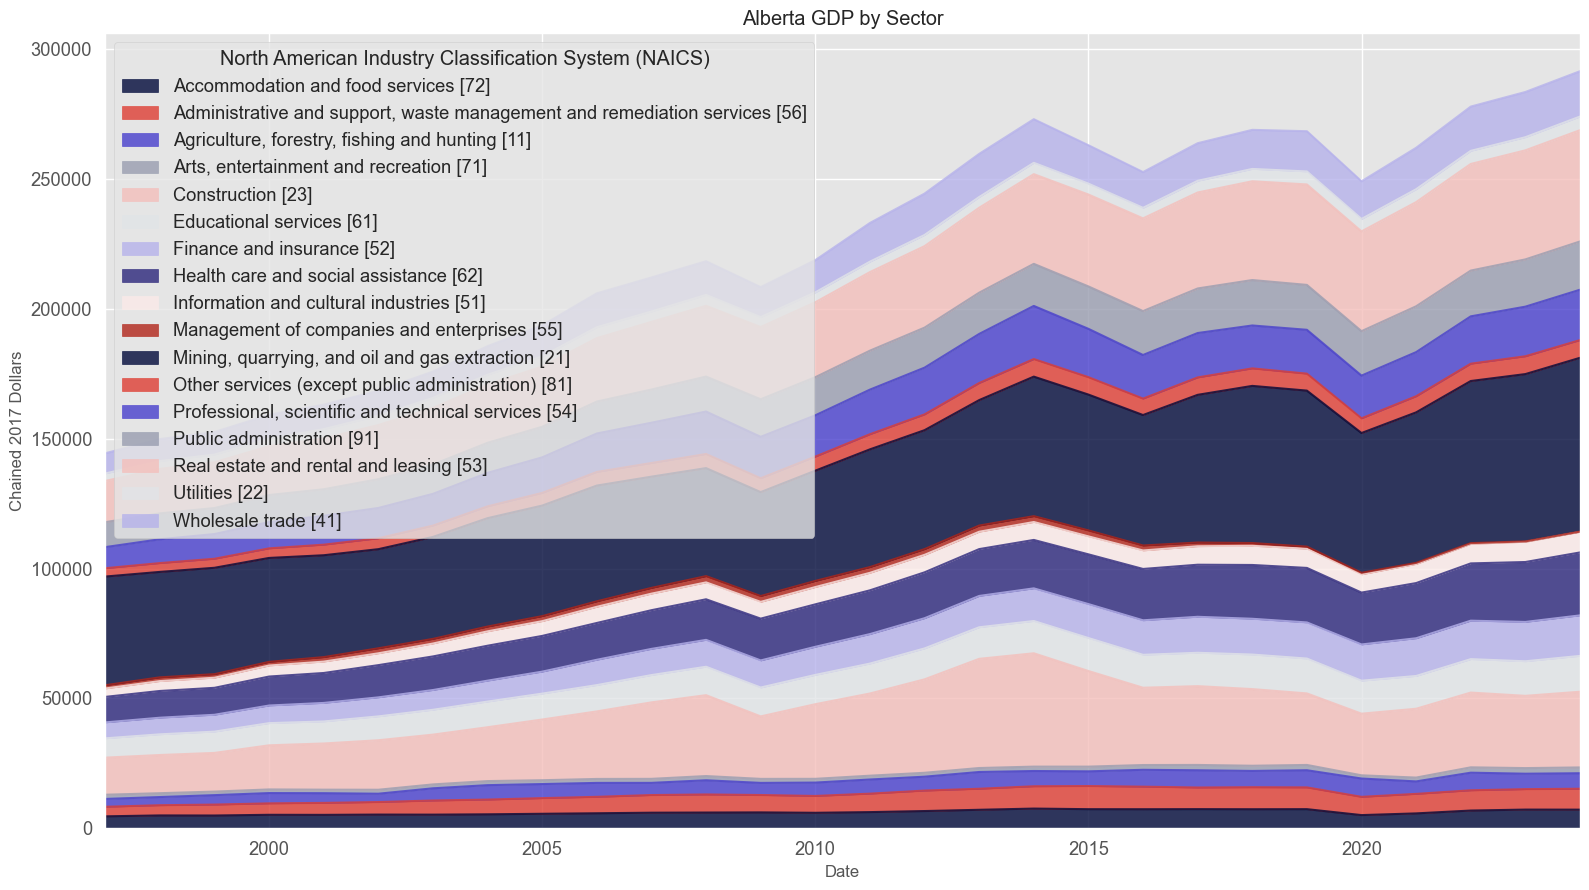

In [68]:
ab_sector.plot.area(stacked=True, alpha=0.8, figsize=(16,9))

plt.title("Alberta GDP by Sector")
plt.ylabel("Chained 2017 Dollars")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


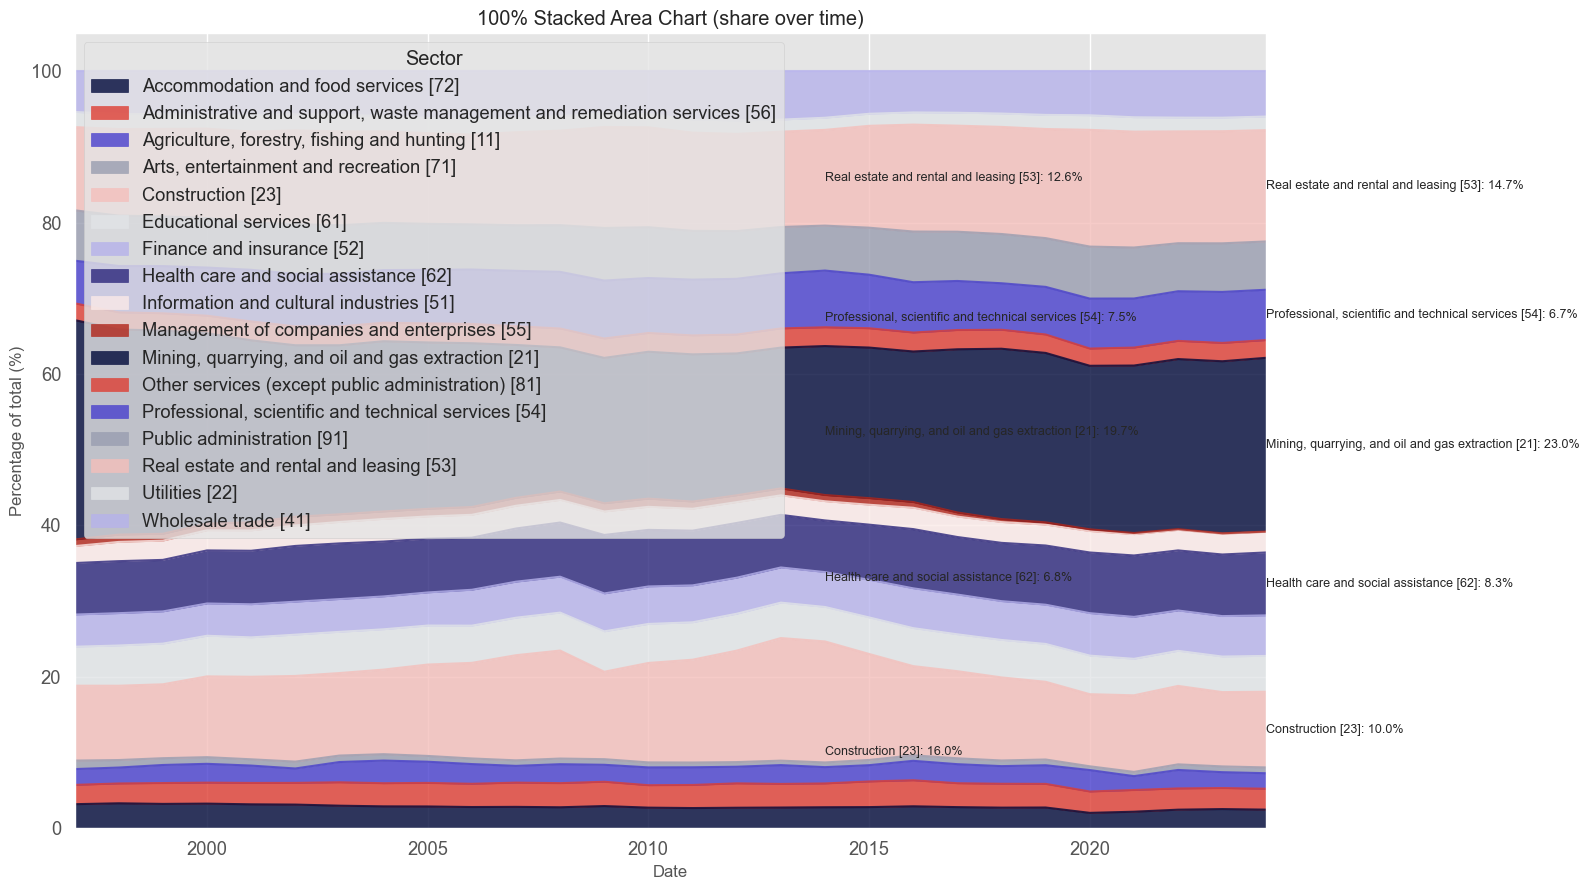

In [95]:
ab_sector_pct = ab_sector.div(ab_sector.sum(axis=1), axis=0) * 100

# Plot as stacked area (100% stacked chart)
ax = ab_sector_pct.plot.area(stacked=True, alpha=0.8, figsize=(16,9))

last_date = ab_sector_pct.index[-1]
mid_date = ab_sector_pct.index[17]

def annotate_top5(date, ax, x_offset=5):
    shares = ab_sector_pct.loc[date].sort_values(ascending=False).head(5)
    cum_sum = ab_sector_pct.loc[ab_sector_pct.index[-1]].cumsum()


    for col in shares.index:
        y_bottom = cum_sum[col] - ab_sector_pct.loc[date, col]
        y_pos = y_bottom + ab_sector_pct.loc[date, col] / 2  # middle of band
        ax.text(
            date + pd.Timedelta(days=x_offset),  # offset outside chart
            y_pos,
            f"{col}: {shares[col]:.1f}%",
            ha="left", va="center", fontsize=9
        )

# Annotate for last and middle date
annotate_top5(last_date, ax)
annotate_top5(mid_date, ax)


plt.title("100% Stacked Area Chart (share over time)")
plt.ylabel("Percentage of total (%)")
plt.xlabel("Date")
plt.legend(title="Sector")
plt.tight_layout()
plt.show()


In [100]:
ab_pivot[ab_pivot.columns[ab_pivot.columns.str.contains('Oil')]]

North American Industry Classification System (NAICS),Oil and gas engineering construction [23C2],Oil and gas extraction (except oil sands) [21111],Oil and gas extraction [211],Oil sands extraction [21114]
REF_DATE,,,,
1997-01-01,8801.2,NaN,32248.3,NaN
1998-01-01,6034.4,NaN,31098.6,NaN
1999-01-01,5536.2,NaN,32746.6,NaN
2000-01-01,7978.8,NaN,30677.5,NaN
2001-01-01,8686.5,NaN,29660.2,NaN
2002-01-01,7954.4,NaN,28960.6,NaN
2003-01-01,8914.4,NaN,29627.9,NaN
2004-01-01,10666.4,NaN,31311.4,NaN
2005-01-01,12591.9,NaN,31518.7,NaN
